# EDGE AI Battery Monitoring — SOC Estimation (Comparative Study)

**Goal:** Estimate live State of Charge (SOC, 0-100%) from voltage/current/temperature, using 3 models suited for eventual ESP32-S3 deployment via TFLite Micro.

**Models compared:**
1. Random Forest (classical ML baseline, windowed statistical features)
2. MLP / Feedforward Neural Network (flattened window, TFLite Micro friendly)
3. LSTM (sequence model, best fit for SOC's inherently time-dependent nature)

**Data:** `timeseries_soc_FINAL.csv` — coulomb-counted SOC ground truth per timestep, extracted from NASA `.mat` battery cycling data (32 batteries, cleaned).

**Split strategy:** by *battery*, not by cycle — some whole batteries are held out for testing, so the models are evaluated on batteries never seen in training. This is stricter (and more honest) than a random row-level split, which would leak information between cycles of the same battery.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Everything imported successfully")
print("TensorFlow:", tf.__version__)

Everything imported successfully
TensorFlow: 2.21.0


## 1. Load data

In [3]:
df = pd.read_csv('timeseries_soc_FINAL.csv')
print(df.shape)
print(df['battery_id'].nunique(), 'batteries')
df.head()


(738908, 8)
32 batteries


,battery_id,cycle,t_s,voltage,current,temperature,soc,cycle_capacity_Ah
0,B0005,1,0.000,4.191492,-0.004902,24.330034,100.000000,1.856487
1,B0005,1,16.781,4.190749,-0.001478,24.325993,99.999199,1.856487
2,B0005,1,35.703,3.974871,-2.012528,24.389085,99.714095,1.856487
3,B0005,1,53.781,3.951717,-2.013979,24.544752,99.169524,1.856487
4,B0005,1,71.922,3.934352,-2.011144,24.731385,98.623243,1.856487


## 2. Resample to a uniform time grid

NASA's logger sampled at an irregular interval (~9-14s median, varies by battery). Your ESP32-S3 will sample at a fixed rate in deployment, so we resample every cycle onto a uniform grid (default: every 10s) via linear interpolation, before building windows.


In [4]:
def resample_cycle(g, dt=10.0):
    g = g.sort_values('t_s')
    t_max = g['t_s'].max()
    new_t = np.arange(0, t_max, dt)
    if len(new_t) < 5:
        return None
    out = pd.DataFrame({'t_s': new_t})
    for col in ['voltage', 'current', 'temperature', 'soc']:
        out[col] = np.interp(new_t, g['t_s'], g[col])
    out['battery_id'] = g['battery_id'].iloc[0]
    out['cycle'] = g['cycle'].iloc[0]
    return out

resampled = []
for (b, c), g in df.groupby(['battery_id', 'cycle']):
    r = resample_cycle(g)
    if r is not None:
        resampled.append(r)

res_df = pd.concat(resampled, ignore_index=True)
print('Resampled shape:', res_df.shape)
res_df.to_csv('resampled_soc.csv', index=False)


Resampled shape: (865594, 7)


## 3. Battery-level train/test split

Holding out entire batteries (not just cycles) for testing gives an honest estimate of how the model generalizes to a battery it has never seen — the real deployment scenario.


In [5]:
batteries = sorted(res_df['battery_id'].unique())
print(len(batteries), 'batteries total')

rng = np.random.RandomState(42)
shuffled = rng.permutation(batteries)
n_test = max(1, int(len(batteries) * 0.2))
test_batteries = set(shuffled[:n_test])
train_batteries = set(shuffled[n_test:])

print('Test batteries (held out):', sorted(test_batteries))
print('Train batteries:', len(train_batteries))


32 batteries total
Test batteries (held out): [np.str_('B0029'), np.str_('B0030'), np.str_('B0038'), np.str_('B0040'), np.str_('B0047'), np.str_('B0054')]
Train batteries: 26


## 4. Build sliding windows

Each model sees a **window** of the last `WINDOW` timesteps (voltage, current, temperature) and predicts the SOC at the current timestep. `WINDOW=12` with a 10s grid = 120 seconds of lookback — adjust based on your ESP32's sampling rate and available RAM.


In [6]:
WINDOW = 12  # number of past timesteps in each input window

def make_windows(sub_df, window=WINDOW):
    X, y = [], []
    for (b, c), g in sub_df.groupby(['battery_id', 'cycle']):
        g = g.sort_values('t_s')
        v = g['voltage'].values
        i = g['current'].values
        t = g['temperature'].values
        soc = g['soc'].values
        for k in range(window, len(g)):
            X.append(np.stack([v[k-window:k], i[k-window:k], t[k-window:k]], axis=1))
            y.append(soc[k])
    return np.array(X), np.array(y)

train_df = res_df[res_df['battery_id'].isin(train_batteries)]
test_df = res_df[res_df['battery_id'].isin(test_batteries)]

print('Building training windows...')
X_train, y_train = make_windows(train_df)
print('Building test windows...')
X_test, y_test = make_windows(test_df)

print('X_train:', X_train.shape, ' y_train:', y_train.shape)
print('X_test:', X_test.shape, ' y_test:', y_test.shape)


Building training windows...
Building test windows...
X_train: (724452, 12, 3)  y_train: (724452,)
X_test: (110854, 12, 3)  y_test: (110854,)


## 5. Normalize inputs

Fit the scaler on **training data only** to avoid leaking test-set statistics.


In [7]:
mean = X_train.reshape(-1, 3).mean(axis=0)
std = X_train.reshape(-1, 3).std(axis=0)

X_train_n = (X_train - mean) / std
X_test_n = (X_test - mean) / std

print('Feature means (V, I, T):', mean)
print('Feature stds  (V, I, T):', std)


Feature means (V, I, T): [ 3.42726816 -1.59422595 26.97717872]
Feature stds  (V, I, T): [ 0.29620104  1.08795212 13.13748771]


## 6. Model 1 — Random Forest (classical ML baseline)

Uses engineered per-window statistics (mean/min/max/last value/delta) rather than the raw sequence, since tree ensembles don't natively exploit sequence order.


In [8]:
def flatten_stats(X):
    feats = []
    for ch in range(X.shape[2]):
        c = X[:, :, ch]
        feats += [c.mean(axis=1), c.min(axis=1), c.max(axis=1), c[:, -1], c[:, -1] - c[:, 0]]
    return np.stack(feats, axis=1)

X_train_feat = flatten_stats(X_train_n)
X_test_feat = flatten_stats(X_test_n)

rf = RandomForestRegressor(n_estimators=200, max_depth=14, n_jobs=-1, random_state=42)
rf.fit(X_train_feat, y_train)

rf_pred = rf.predict(X_test_feat)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f'Random Forest -> MAE: {rf_mae:.3f}  RMSE: {rf_rmse:.3f}  R2: {rf_r2:.4f}')


Random Forest -> MAE: 3.335  RMSE: 5.373  R2: 0.9692


## 7. Model 2 — MLP (Feedforward Neural Network)

Flattens the window into a single vector. Simple, fast, and directly convertible to TFLite Micro for ESP32-S3.


In [9]:
X_train_flat = X_train_n.reshape(len(X_train_n), -1)
X_test_flat = X_test_n.reshape(len(X_test_n), -1)

mlp = keras.Sequential([
    keras.layers.Input(shape=(X_train_flat.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])
mlp.compile(optimizer='adam', loss='mse')

history_mlp = mlp.fit(
    X_train_flat, y_train,
    validation_split=0.1,
    epochs=30, batch_size=512, verbose=1
)

mlp_pred = mlp.predict(X_test_flat, verbose=0).flatten()
mlp_mae = mean_absolute_error(y_test, mlp_pred)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
mlp_r2 = r2_score(y_test, mlp_pred)
print(f'MLP -> MAE: {mlp_mae:.3f}  RMSE: {mlp_rmse:.3f}  R2: {mlp_r2:.4f}')


Epoch 1/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - loss: 359.0667 - val_loss: 417.2294
Epoch 2/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 36.7051 - val_loss: 256.4062
Epoch 3/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 31.3682 - val_loss: 148.3619
Epoch 4/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 28.5558 - val_loss: 123.5296
Epoch 5/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 26.8583 - val_loss: 108.1414
Epoch 6/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 25.6775 - val_loss: 130.4046
Epoch 7/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 24.5992 - val_loss: 190.3448
Epoch 8/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 23.6633 - val_loss: 318.6368
Epoch 9/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 22.8608 - val_loss: 490.7599
Epoch 10/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 22.0810 - val_loss: 622.1475
Epoch 11/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 21.4393 - val_loss: 764.

## 8. Model 3 — LSTM (sequence model)

Takes the raw (voltage, current, temperature) sequence directly, without manual feature engineering — best suited to SOC since it's inherently a time-dependent quantity.


In [10]:
lstm = keras.Sequential([
    keras.layers.Input(shape=(X_train_n.shape[1], X_train_n.shape[2])),
    keras.layers.LSTM(32),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')

history_lstm = lstm.fit(
    X_train_n, y_train,
    validation_split=0.1,
    epochs=30, batch_size=512, verbose=1
)

lstm_pred = lstm.predict(X_test_n, verbose=0).flatten()
lstm_mae = mean_absolute_error(y_test, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
lstm_r2 = r2_score(y_test, lstm_pred)
print(f'LSTM -> MAE: {lstm_mae:.3f}  RMSE: {lstm_rmse:.3f}  R2: {lstm_r2:.4f}')


Epoch 1/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 255s 10ms/step - loss: 379.4323 - val_loss: 231.2771
Epoch 2/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 25.2634 - val_loss: 101.3064
Epoch 3/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 23.0764 - val_loss: 118.1757
Epoch 4/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 22.1605 - val_loss: 126.4598
Epoch 5/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 21.4185 - val_loss: 117.2196
Epoch 6/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 20.5921 - val_loss: 105.1833
Epoch 7/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 19.7651 - val_loss: 119.6005
Epoch 8/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 18.9226 - val_loss: 142.7615
Epoch 9/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 18.2801 - val_loss: 161.8750
Epoch 10/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 17.8682 - val_loss: 186.7043
Epoch 11/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 17.4

## 9. Comparative results

In [11]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'MLP', 'LSTM'],
    'MAE (%)': [rf_mae, mlp_mae, lstm_mae],
    'RMSE (%)': [rf_rmse, mlp_rmse, lstm_rmse],
    'R2': [rf_r2, mlp_r2, lstm_r2],
    'Params/Nodes': [rf.n_estimators, mlp.count_params(), lstm.count_params()]
})
results


,Model,MAE (%),RMSE (%),R2,Params/Nodes
0,Random Forest,3.334830,5.372840,0.969151,200
1,MLP,9.421821,17.790864,0.661755,1729
2,LSTM,5.290755,8.788137,0.917466,5153


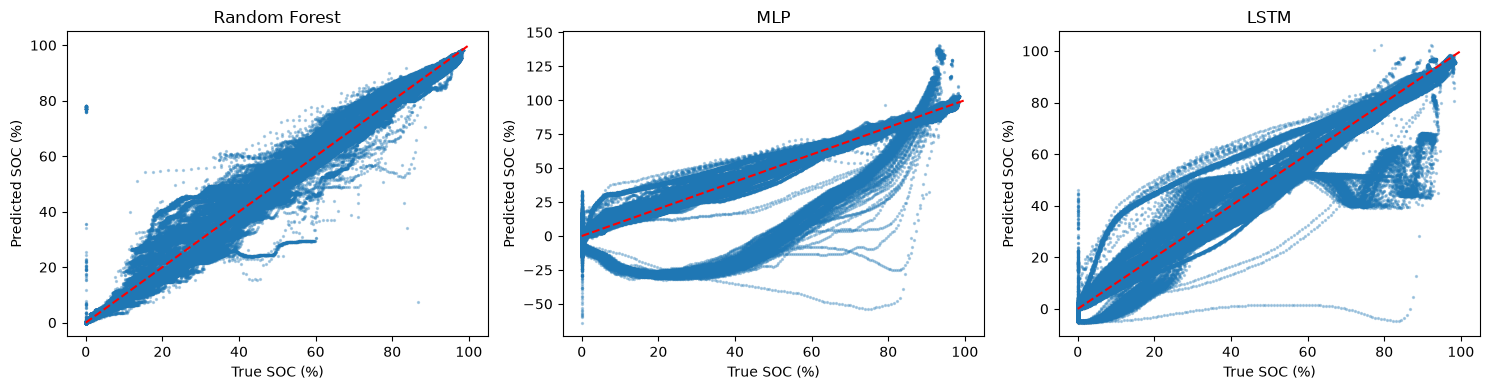

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, [('Random Forest', rf_pred), ('MLP', mlp_pred), ('LSTM', lstm_pred)]):
    ax.scatter(y_test, pred, s=2, alpha=0.3)
    ax.plot([0, 100], [0, 100], 'r--')
    ax.set_xlabel('True SOC (%)')
    ax.set_ylabel('Predicted SOC (%)')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('soc_model_comparison.png', dpi=120)
plt.show()


## 10. Edge deployment notes (ESP32-S3)

- **MLP and LSTM** convert directly to TFLite Micro (`tf.lite.TFLiteConverter`), then to a `.tflite` file, then to a C byte array for flashing.
- **Random Forest** doesn't have a native TFLite path — export it as C code instead (e.g. via `emlearn` or `m2cgen`), or use it only as your offline comparative baseline rather than the deployed model.
- Apply **post-training int8 quantization** on the MLP/LSTM before conversion — cuts model size ~4x with usually small accuracy loss, and ESP32-S3 has hardware acceleration for int8 ops.
- Keep `WINDOW` small (12-20 steps) to limit the RAM needed to buffer the input sequence on-device.
- Next notebook: reuse this same pattern (windowing, battery-level split, 3-model comparison) for **SOH** and **RUL**, using the cycle-level summary CSV instead of the timeseries one.


## THE RANDOFM FORREST WINS. BOTH THE OTHERS ARE HEAVILY OVER FIT. SO LETS LEARN THE DATA 

In [13]:
df = pd.read_csv('timeseries_soc_FINAL.csv')
print(df.shape)
df.head()

(738908, 8)


,battery_id,cycle,t_s,voltage,current,temperature,soc,cycle_capacity_Ah
0,B0005,1,0.000,4.191492,-0.004902,24.330034,100.000000,1.856487
1,B0005,1,16.781,4.190749,-0.001478,24.325993,99.999199,1.856487
2,B0005,1,35.703,3.974871,-2.012528,24.389085,99.714095,1.856487
3,B0005,1,53.781,3.951717,-2.013979,24.544752,99.169524,1.856487
4,B0005,1,71.922,3.934352,-2.011144,24.731385,98.623243,1.856487


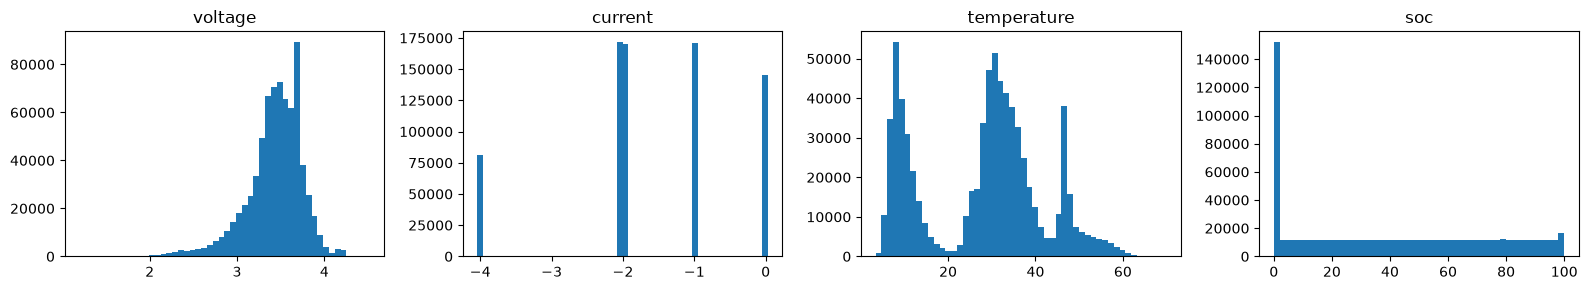

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, col in zip(axes, ['voltage', 'current', 'temperature', 'soc']):
    ax.hist(df[col], bins=50)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [15]:
corr = df[['voltage', 'current', 'temperature', 'soc']].corr()
print(corr)

              voltage   current  temperature       soc
voltage      1.000000  0.332802    -0.027042  0.559522
current      0.332802  1.000000    -0.289832 -0.310791
temperature -0.027042 -0.289832     1.000000 -0.180674
soc          0.559522 -0.310791    -0.180674  1.000000


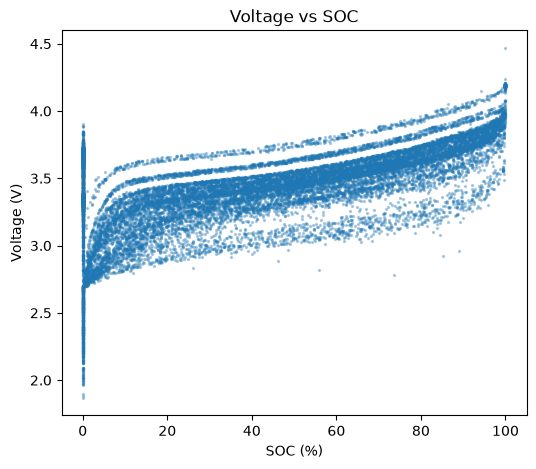

In [16]:
sample = df.sample(20000, random_state=0)  # subsample for a readable scatter
plt.figure(figsize=(6,5))
plt.scatter(sample['soc'], sample['voltage'], s=2, alpha=0.3)
plt.xlabel('SOC (%)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs SOC')
plt.show()

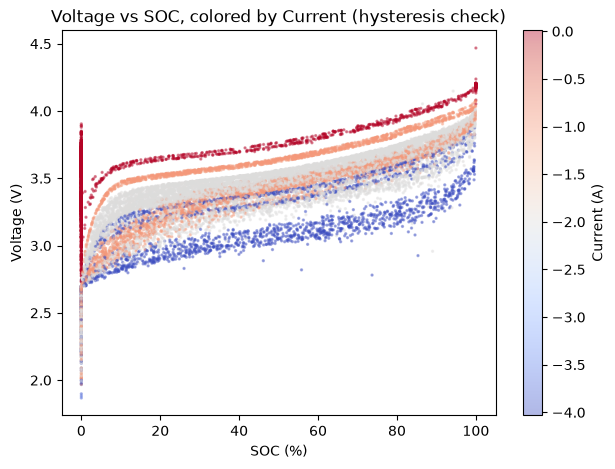

In [17]:
plt.figure(figsize=(7,5))
sc = plt.scatter(sample['soc'], sample['voltage'], c=sample['current'], s=2, alpha=0.4, cmap='coolwarm')
plt.colorbar(sc, label='Current (A)')
plt.xlabel('SOC (%)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs SOC, colored by Current (hysteresis check)')
plt.show()

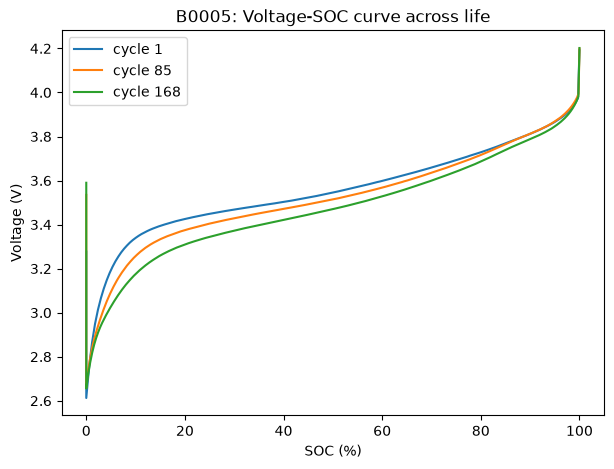

In [18]:
b = 'B0005'
sub = df[df['battery_id']==b]
cycles_available = sorted(sub['cycle'].unique())
picks = [cycles_available[0], cycles_available[len(cycles_available)//2], cycles_available[-1]]

plt.figure(figsize=(7,5))
for c in picks:
    g = sub[sub['cycle']==c]
    plt.plot(g['soc'], g['voltage'], label=f'cycle {c}')
plt.xlabel('SOC (%)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.title(f'{b}: Voltage-SOC curve across life')
plt.show()

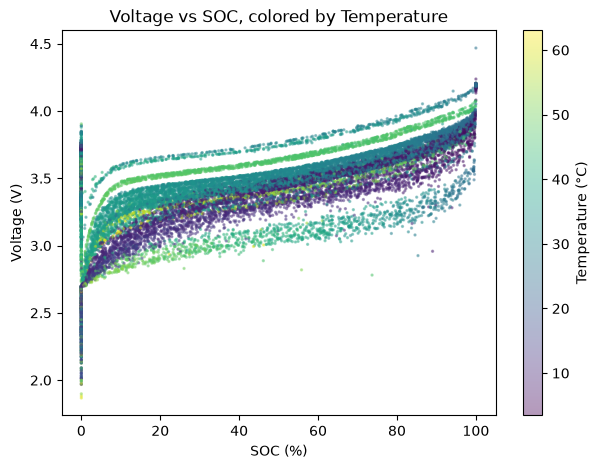

In [19]:
plt.figure(figsize=(7,5))
sc = plt.scatter(sample['soc'], sample['voltage'], c=sample['temperature'], s=2, alpha=0.4, cmap='viridis')
plt.colorbar(sc, label='Temperature (°C)')
plt.xlabel('SOC (%)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs SOC, colored by Temperature')
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [21]:
df = pd.read_csv('timeseries_soc_FINAL.csv')
print(df.shape)

(738908, 8)


In [22]:
def truncate_after_first_zero(df):
    kept = []
    for (b, c), g in df.groupby(['battery_id', 'cycle']):
        g = g.sort_values('t_s')
        zero_idx = g.index[g['soc'] <= 0]
        if len(zero_idx) > 0:
            first_zero = zero_idx[0]
            g = g.loc[:first_zero]
        kept.append(g)
    return pd.concat(kept, ignore_index=True)

df_clean = truncate_after_first_zero(df)
print("Before:", df.shape, " After:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))

Before: (738908, 8)  After: (600366, 8)
Rows removed: 138542


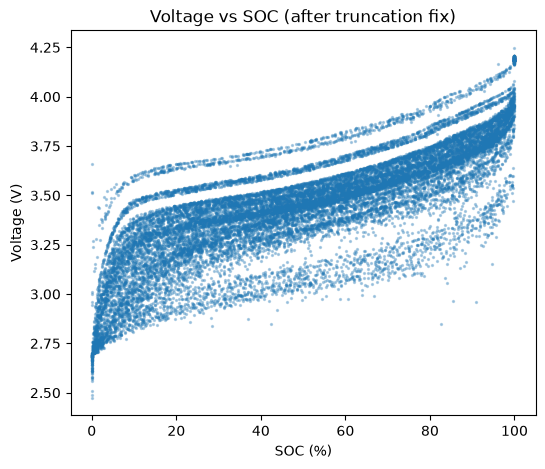

In [23]:
sample = df_clean.sample(20000, random_state=0)
plt.figure(figsize=(6,5))
plt.scatter(sample['soc'], sample['voltage'], s=2, alpha=0.3)
plt.xlabel('SOC (%)'); plt.ylabel('Voltage (V)')
plt.title('Voltage vs SOC (after truncation fix)')
plt.show()

In [24]:
protocol_check = df_clean.groupby('battery_id').agg(
    currents=('current', lambda x: sorted(x.round().unique())),
    temp_mean=('temperature', 'mean')
)
print(protocol_check)

                            currents  temp_mean
battery_id                                     
B0005                   [-2.0, -0.0]  32.283889
B0006                   [-2.0, -0.0]  32.229567
B0007                   [-2.0, -0.0]  32.029258
B0018                    [-2.0, 0.0]  30.616126
B0025                    [-4.0, 0.0]  34.691157
B0026                   [-4.0, -0.0]  34.667697
B0027                   [-4.0, -0.0]  37.129170
B0028                    [-2.0, 0.0]  30.320370
B0029                   [-4.0, -0.0]  52.563786
B0030                    [-4.0, 0.0]  53.694590
B0031                   [-4.0, -0.0]  53.641528
B0032                   [-4.0, -0.0]  54.232939
B0033                   [-4.0, -0.0]  39.458469
B0034                   [-4.0, -0.0]  40.355275
B0036                   [-2.0, -0.0]  30.652566
B0038       [-4.0, -2.0, -1.0, -0.0]  46.814531
B0039       [-4.0, -2.0, -1.0, -0.0]  46.835290
B0040       [-4.0, -2.0, -1.0, -0.0]  45.985448
B0041                   [-1.0, -0.0]   8

In [25]:
def resample_cycle(g, dt=10.0):
    g = g.sort_values('t_s')
    t_max = g['t_s'].max()
    new_t = np.arange(0, t_max, dt)
    if len(new_t) < 5:
        return None
    out = pd.DataFrame({'t_s': new_t})
    for col in ['voltage', 'current', 'temperature', 'soc']:
        out[col] = np.interp(new_t, g['t_s'], g[col])
    out['battery_id'] = g['battery_id'].iloc[0]
    out['cycle'] = g['cycle'].iloc[0]
    out['cycle_capacity_Ah'] = g['cycle_capacity_Ah'].iloc[0]
    return out

resampled = []
for (b, c), g in df_clean.groupby(['battery_id', 'cycle']):
    r = resample_cycle(g)
    if r is not None:
        resampled.append(r)

res_df = pd.concat(resampled, ignore_index=True)
print('Resampled shape:', res_df.shape)
res_df.to_csv('resampled_soc_clean.csv', index=False)

Resampled shape: (696101, 8)


In [26]:
batteries = sorted(res_df['battery_id'].unique())
rng = np.random.RandomState(42)
shuffled = rng.permutation(batteries)
n_test = max(1, int(len(batteries) * 0.2))
test_batteries = set(shuffled[:n_test])
train_batteries = set(shuffled[n_test:])

print('Test batteries:', sorted(test_batteries))
print('Train batteries:', len(train_batteries))

Test batteries: [np.str_('B0029'), np.str_('B0030'), np.str_('B0038'), np.str_('B0040'), np.str_('B0047'), np.str_('B0054')]
Train batteries: 26


In [27]:
WINDOW = 12

def make_windows(sub_df, window=WINDOW):
    X, y = [], []
    for (b, c), g in sub_df.groupby(['battery_id', 'cycle']):
        g = g.sort_values('t_s')
        v, i, t, soc = g['voltage'].values, g['current'].values, g['temperature'].values, g['soc'].values
        for k in range(window, len(g)):
            X.append(np.stack([v[k-window:k], i[k-window:k], t[k-window:k]], axis=1))
            y.append(soc[k])
    return np.array(X), np.array(y)

train_df = res_df[res_df['battery_id'].isin(train_batteries)]
test_df = res_df[res_df['battery_id'].isin(test_batteries)]

X_train, y_train = make_windows(train_df)
X_test, y_test = make_windows(test_df)
print(X_train.shape, X_test.shape)

(568404, 12, 3) (97409, 12, 3)


In [28]:
mean = X_train.reshape(-1, 3).mean(axis=0)
std = X_train.reshape(-1, 3).std(axis=0)
X_train_n = (X_train - mean) / std
X_test_n = (X_test - mean) / std

In [29]:
# Load each battery's rated (reference) capacity — known in advance, not the
# per-cycle true capacity, since that's only knowable in hindsight
summary = pd.read_csv('cycle_summary_soh_rul_FINAL.csv')
rated_capacity_map = summary.groupby('battery_id')['rated_capacity_Ah'].first().to_dict()

def coulomb_counting_soc_realistic(g, rated_capacity_Ah):
    g = g.sort_values('t_s')
    dt_hours = g['t_s'].diff().fillna(0) / 3600.0
    cum_Ah = (g['current'].abs() * dt_hours).cumsum()
    soc_est = 100 * (1 - cum_Ah / rated_capacity_Ah)
    return np.clip(soc_est, 0, 100)

cc_preds, cc_true = [], []
for (b, c), g in test_df.groupby(['battery_id', 'cycle']):
    rated_cap = rated_capacity_map[b]
    est = coulomb_counting_soc_realistic(g, rated_cap)
    cc_preds.extend(est.values[WINDOW:])
    cc_true.extend(g.sort_values('t_s')['soc'].values[WINDOW:])

cc_mae = mean_absolute_error(cc_true, cc_preds)
cc_rmse = np.sqrt(mean_squared_error(cc_true, cc_preds))
cc_r2 = r2_score(cc_true, cc_preds)
print(f'Coulomb Counting (realistic) -> MAE: {cc_mae:.3f}  RMSE: {cc_rmse:.3f}  R2: {cc_r2:.4f}')

Coulomb Counting (realistic) -> MAE: 4.266  RMSE: 7.540  R2: 0.9273


In [30]:
def flatten_stats(X):
    feats = []
    for ch in range(X.shape[2]):
        c = X[:, :, ch]
        feats += [c.mean(axis=1), c.min(axis=1), c.max(axis=1), c[:, -1], c[:, -1] - c[:, 0]]
    return np.stack(feats, axis=1)

X_train_feat = flatten_stats(X_train_n)
X_test_feat = flatten_stats(X_test_n)

rf = RandomForestRegressor(n_estimators=200, max_depth=14, n_jobs=-1, random_state=42)
rf.fit(X_train_feat, y_train)
rf_pred = rf.predict(X_test_feat)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f'Random Forest -> MAE: {rf_mae:.3f}  RMSE: {rf_rmse:.3f}  R2: {rf_r2:.4f}')

Random Forest -> MAE: 3.587  RMSE: 5.152  R2: 0.9661


In [31]:
X_train_flat = X_train_n.reshape(len(X_train_n), -1)
X_test_flat = X_test_n.reshape(len(X_test_n), -1)

mlp = keras.Sequential([
    keras.layers.Input(shape=(X_train_flat.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
mlp.compile(optimizer='adam', loss='mse')
early_stop_mlp = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_mlp = mlp.fit(X_train_flat, y_train, validation_split=0.1,
                       epochs=30, batch_size=512, verbose=1, callbacks=[early_stop_mlp])

mlp_pred = mlp.predict(X_test_flat, verbose=0).flatten()
mlp_mae = mean_absolute_error(y_test, mlp_pred)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
mlp_r2 = r2_score(y_test, mlp_pred)
print(f'MLP -> MAE: {mlp_mae:.3f}  RMSE: {mlp_rmse:.3f}  R2: {mlp_r2:.4f}')
print(f'Stopped at epoch {len(history_mlp.history["loss"])}')

Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 608.3306 - val_loss: 143.4542
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 182.2219 - val_loss: 147.3356
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 163.9907 - val_loss: 126.9125
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 161.7202 - val_loss: 122.5363
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 158.1952 - val_loss: 114.2026
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 154.5147 - val_loss: 123.8820
Epoch 7/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 150.7382 - val_loss: 136.0460
Epoch 8/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 146.6207 - val_loss: 137.5157
Epoch 9/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 142.8954 - val_loss: 151.6082
Epoch 10/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 138.9072 - val_loss: 151.9239
MLP -> MAE: 6.100  RMSE: 8.039  R2: 0.9174
Stopped at epoch 10


In [32]:
lstm = keras.Sequential([
    keras.layers.Input(shape=(X_train_n.shape[1], X_train_n.shape[2])),
    keras.layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = lstm.fit(X_train_n, y_train, validation_split=0.1,
                         epochs=30, batch_size=512, verbose=1, callbacks=[early_stop_lstm])

lstm_pred = lstm.predict(X_test_n, verbose=0).flatten()
lstm_mae = mean_absolute_error(y_test, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
lstm_r2 = r2_score(y_test, lstm_pred)
print(f'LSTM -> MAE: {lstm_mae:.3f}  RMSE: {lstm_rmse:.3f}  R2: {lstm_r2:.4f}')
print(f'Stopped at epoch {len(history_lstm.history["loss"])}')

Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 613s 43ms/step - loss: 662.0671 - val_loss: 84.0212
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 208.2040 - val_loss: 122.0480
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 192.8518 - val_loss: 154.1757
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 183.2085 - val_loss: 174.7684
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 176.3322 - val_loss: 182.8430
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 170.2396 - val_loss: 193.8274
LSTM -> MAE: 6.665  RMSE: 8.638  R2: 0.9046
Stopped at epoch 6


In [33]:
results = pd.DataFrame({
    'Model': ['Coulomb Counting', 'Random Forest', 'MLP', 'LSTM'],
    'MAE (%)': [cc_mae, rf_mae, mlp_mae, lstm_mae],
    'RMSE (%)': [cc_rmse, rf_rmse, mlp_rmse, lstm_rmse],
    'R2': [cc_r2, rf_r2, mlp_r2, lstm_r2]
})
results

,Model,MAE (%),RMSE (%),R2
0,Coulomb Counting,4.265573,7.539591,0.927342
1,Random Forest,3.586516,5.151521,0.966080
2,MLP,6.100369,8.039139,0.917395
3,LSTM,6.664882,8.637988,0.904630


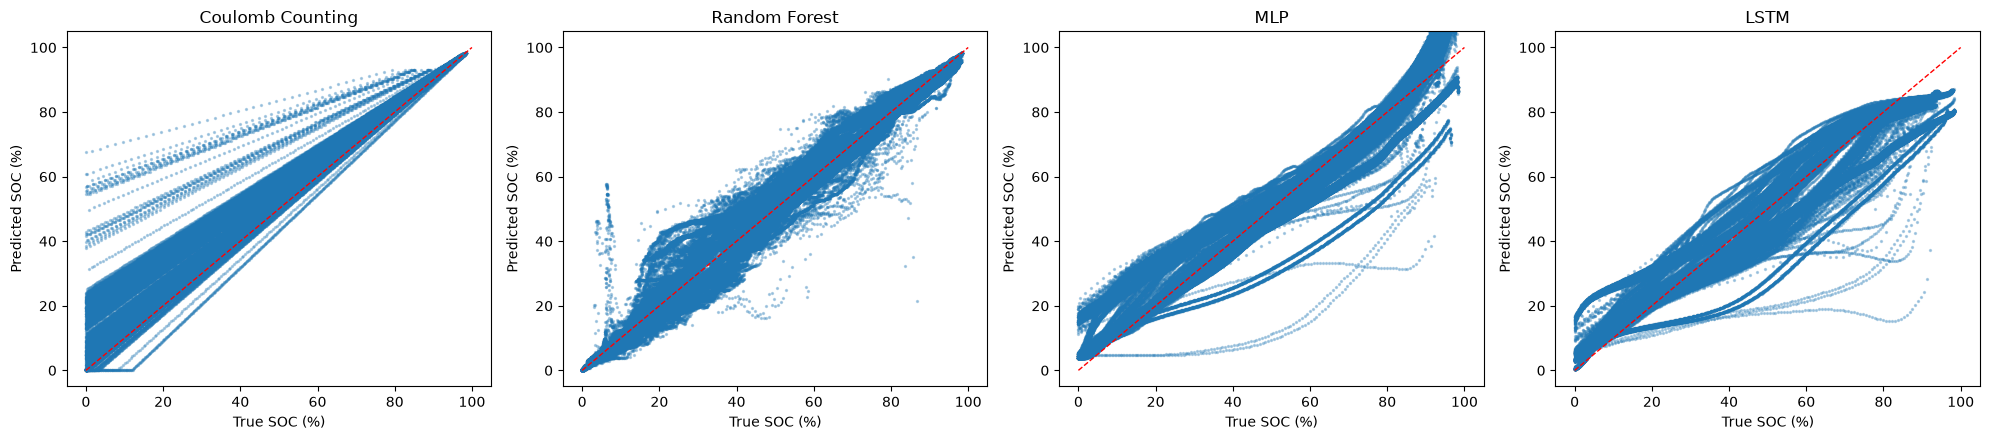

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

model_data = [
    ('Coulomb Counting', cc_true, cc_preds),
    ('Random Forest', y_test, rf_pred),
    ('MLP', y_test, mlp_pred),
    ('LSTM', y_test, lstm_pred),
]

for ax, (name, true_vals, pred_vals) in zip(axes, model_data):
    ax.scatter(true_vals, pred_vals, s=2, alpha=0.3)
    ax.plot([0, 100], [0, 100], 'r--', linewidth=1)
    ax.set_xlabel('True SOC (%)')
    ax.set_ylabel('Predicted SOC (%)')
    ax.set_title(name)
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)

plt.tight_layout()
plt.savefig('soc_model_comparison_v2.png', dpi=120)
plt.show()

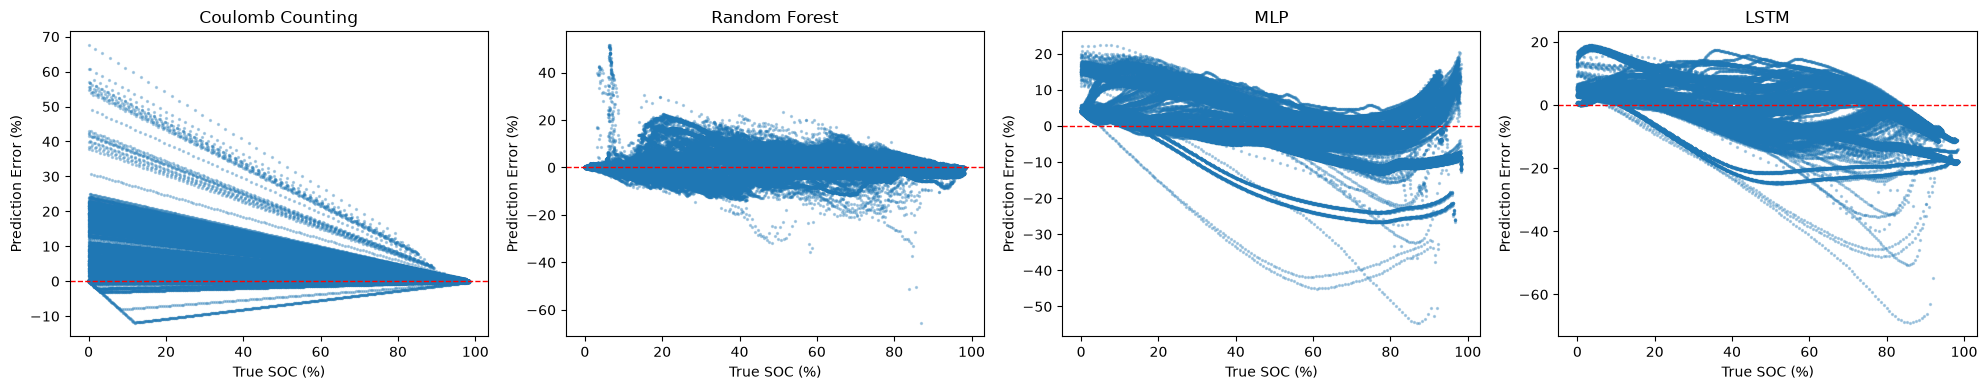

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, true_vals, pred_vals) in zip(axes, model_data):
    err = np.array(pred_vals) - np.array(true_vals)
    ax.scatter(true_vals, err, s=2, alpha=0.3)
    ax.axhline(0, color='r', linestyle='--', linewidth=1)
    ax.set_xlabel('True SOC (%)')
    ax.set_ylabel('Prediction Error (%)')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('soc_error_vs_soc.png', dpi=120)
plt.show()

In [37]:
def make_windows_with_ids(sub_df, window=WINDOW):
    X, y, ids = [], [], []
    for (b, c), g in sub_df.groupby(['battery_id', 'cycle']):
        g = g.sort_values('t_s')
        v, i, t, soc = g['voltage'].values, g['current'].values, g['temperature'].values, g['soc'].values
        for k in range(window, len(g)):
            X.append(np.stack([v[k-window:k], i[k-window:k], t[k-window:k]], axis=1))
            y.append(soc[k])
            ids.append(b)
    return np.array(X), np.array(y), np.array(ids)

X_test_ids, y_test_ids, test_battery_ids = make_windows_with_ids(test_df)

# sanity check — should print True (confirms same order/values as your existing y_test)
print(np.allclose(y_test_ids.astype(float), np.array(y_test).astype(float)))

True


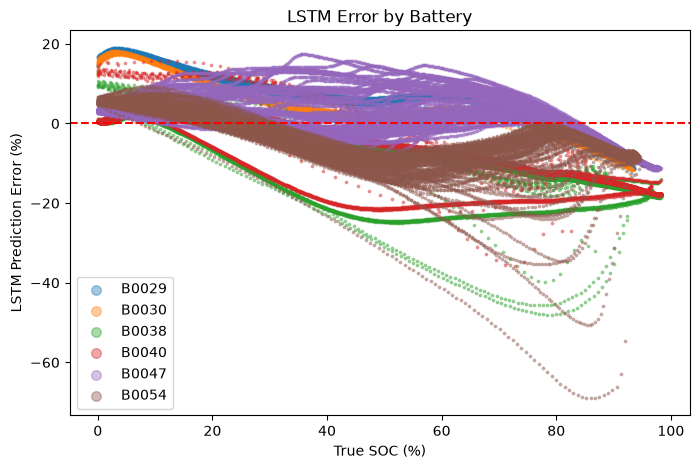

In [39]:
lstm_err = np.array(lstm_pred) - np.array(y_test)

plt.figure(figsize=(8,5))
for b in np.unique(test_battery_ids):
    mask = test_battery_ids == b
    plt.scatter(np.array(y_test)[mask], lstm_err[mask], s=3, alpha=0.4, label=b)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('True SOC (%)')
plt.ylabel('LSTM Prediction Error (%)')
plt.legend(markerscale=4)
plt.title('LSTM Error by Battery')
plt.show()

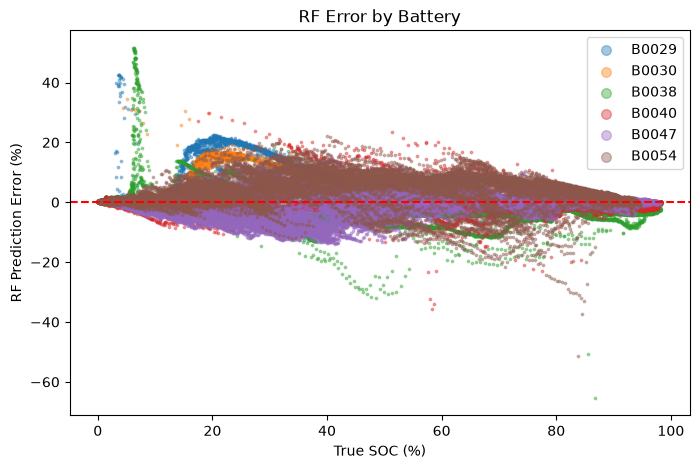

In [40]:
rf_err = rf_pred - y_test
plt.figure(figsize=(8,5))
for b in np.unique(test_battery_ids):
    mask = test_battery_ids == b
    plt.scatter(np.array(y_test)[mask], rf_err[mask], s=3, alpha=0.4, label=b)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('True SOC (%)')
plt.ylabel('RF Prediction Error (%)')
plt.legend(markerscale=4)
plt.title('RF Error by Battery')
plt.show()

In [41]:
# Check where B0038 and B0054 sit vs the rest, in terms of current/temperature regime
check_cols = protocol_check.loc[['B0038', 'B0054']]
print("Suspect batteries:")
print(check_cols)
print()
print("Full training set for comparison:")
print(protocol_check.loc[list(train_batteries)])

Suspect batteries:
                            currents  temp_mean
battery_id                                     
B0038       [-4.0, -2.0, -1.0, -0.0]  46.814531
B0054                    [-2.0, 0.0]  11.177038

Full training set for comparison:
                            currents  temp_mean
battery_id                                     
B0033                   [-4.0, -0.0]  39.458469
B0048                    [-1.0, 0.0]   7.943746
B0032                   [-4.0, -0.0]  54.232939
B0042             [-2.0, -1.0, -0.0]  19.597787
B0027                   [-4.0, -0.0]  37.129170
B0025                    [-4.0, 0.0]  34.691157
B0041                   [-1.0, -0.0]   8.668844
B0055                    [-2.0, 0.0]  10.846049
B0044             [-2.0, -1.0, -0.0]  20.028106
B0039       [-4.0, -2.0, -1.0, -0.0]  46.835290
B0043             [-2.0, -1.0, -0.0]  19.451242
B0031                   [-4.0, -0.0]  53.641528
B0005                   [-2.0, -0.0]  32.283889
B0049                   [-2.0, -0.

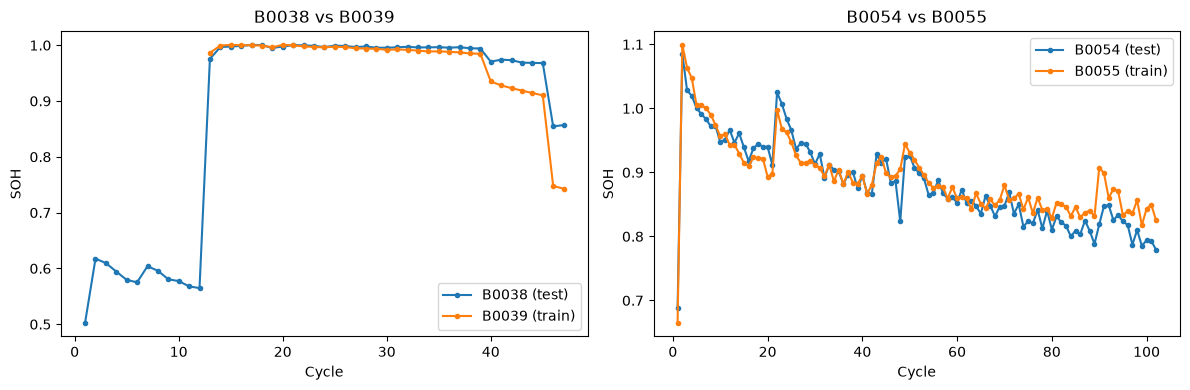

In [42]:
# Compare degradation trajectory: suspect battery vs its regime-twin in training
summary = pd.read_csv('cycle_summary_soh_rul_FINAL.csv')

pairs = [('B0038', 'B0039'), ('B0054', 'B0055')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (suspect, twin) in zip(axes, pairs):
    s1 = summary[summary['battery_id'] == suspect]
    s2 = summary[summary['battery_id'] == twin]
    ax.plot(s1['cycle'], s1['soh'], label=f'{suspect} (test)', marker='.')
    ax.plot(s2['cycle'], s2['soh'], label=f'{twin} (train)', marker='.')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('SOH')
    ax.legend()
    ax.set_title(f'{suspect} vs {twin}')
plt.tight_layout()
plt.show()

In [43]:
cc_battery_ids = []
for (b, c), g in test_df.groupby(['battery_id', 'cycle']):
    n = len(g) - WINDOW
    if n > 0:
        cc_battery_ids.extend([b] * n)
cc_battery_ids = np.array(cc_battery_ids)

print(len(cc_battery_ids), len(cc_true))  # sanity check — should match

97409 97409


In [44]:
def per_battery_mae(true_vals, pred_vals, ids):
    true_vals = np.array(true_vals)
    pred_vals = np.array(pred_vals)
    rows = []
    for b in np.unique(ids):
        mask = ids == b
        mae = mean_absolute_error(true_vals[mask], pred_vals[mask])
        rows.append({'battery_id': b, 'n_rows': mask.sum(), 'mae': mae})
    return pd.DataFrame(rows).set_index('battery_id')

cc_bat = per_battery_mae(cc_true, cc_preds, cc_battery_ids).rename(columns={'mae': 'CC_mae'})
rf_bat = per_battery_mae(y_test, rf_pred, test_battery_ids).rename(columns={'mae': 'RF_mae'})
mlp_bat = per_battery_mae(y_test, mlp_pred, test_battery_ids).rename(columns={'mae': 'MLP_mae'})
lstm_bat = per_battery_mae(y_test, lstm_pred, test_battery_ids).rename(columns={'mae': 'LSTM_mae'})

battery_summary = cc_bat[['n_rows', 'CC_mae']].join(
    [rf_bat['RF_mae'], mlp_bat['MLP_mae'], lstm_bat['LSTM_mae']]
)
battery_summary['temp_mean'] = protocol_check.loc[battery_summary.index, 'temp_mean']
battery_summary = battery_summary.sort_values('RF_mae', ascending=False)
battery_summary

,n_rows,CC_mae,RF_mae,MLP_mae,LSTM_mae,temp_mean
battery_id,,,,,,
B0029,5781,2.424971,6.141309,8.392399,8.372833,52.563786
B0054,16345,5.917495,5.171120,7.485751,6.751634,11.177038
B0030,5555,2.543310,4.426984,5.284288,6.407500,53.694590
B0038,19968,1.486195,4.044930,7.819885,8.638255,46.814531
B0047,30716,7.530634,2.791156,3.767656,4.343953,8.282607
B0040,19044,1.556902,2.007972,6.413083,7.821334,45.985448


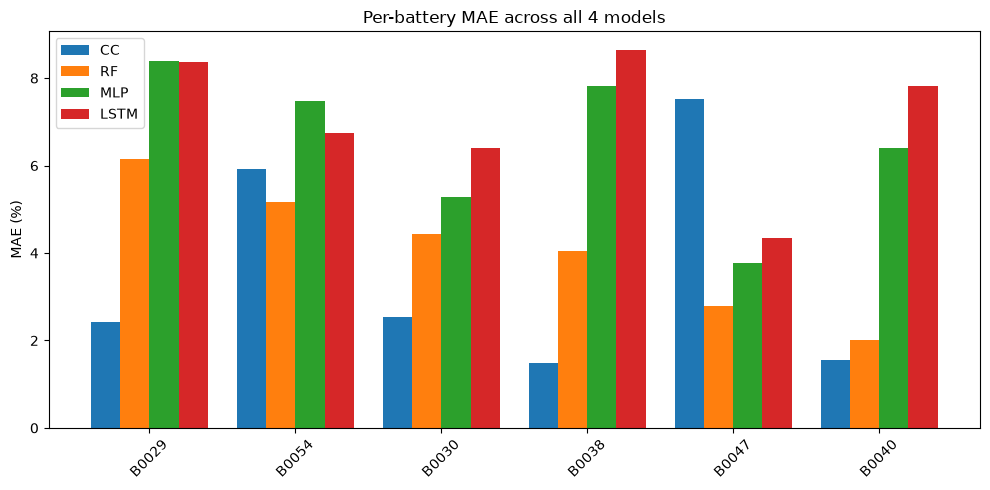

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
models = ['CC_mae', 'RF_mae', 'MLP_mae', 'LSTM_mae']
x = np.arange(len(battery_summary))
width = 0.2

for i, m in enumerate(models):
    ax.bar(x + i*width, battery_summary[m], width, label=m.replace('_mae',''))

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(battery_summary.index, rotation=45)
ax.set_ylabel('MAE (%)')
ax.set_title('Per-battery MAE across all 4 models')
ax.legend()
plt.tight_layout()
plt.savefig('per_battery_mae.png', dpi=120)
plt.show()

In [46]:
n_val = int(len(X_train_n) * 0.1)
val_tail_ids = []
count = 0
for (b, c), g in train_df.groupby(['battery_id', 'cycle']):
    n = len(g) - WINDOW
    if n > 0:
        count += n
print("Total train windows:", count, " | last 10% =", n_val, "rows")

# Rebuild train ids in the same order make_windows used, so we can see the tail
train_ids_ordered = []
for (b, c), g in train_df.groupby(['battery_id', 'cycle']):
    n = len(g) - WINDOW
    if n > 0:
        train_ids_ordered.extend([b] * n)
train_ids_ordered = np.array(train_ids_ordered)

tail_ids = train_ids_ordered[-n_val:]
print("Batteries in the validation_split tail:", np.unique(tail_ids))
print("Full training batteries:", sorted(train_batteries))

Total train windows: 568404  | last 10% = 56840 rows
Batteries in the validation_split tail: ['B0049' 'B0051' 'B0053' 'B0055' 'B0056']
Full training batteries: [np.str_('B0005'), np.str_('B0006'), np.str_('B0007'), np.str_('B0018'), np.str_('B0025'), np.str_('B0026'), np.str_('B0027'), np.str_('B0028'), np.str_('B0031'), np.str_('B0032'), np.str_('B0033'), np.str_('B0034'), np.str_('B0036'), np.str_('B0039'), np.str_('B0041'), np.str_('B0042'), np.str_('B0043'), np.str_('B0044'), np.str_('B0045'), np.str_('B0046'), np.str_('B0048'), np.str_('B0049'), np.str_('B0051'), np.str_('B0053'), np.str_('B0055'), np.str_('B0056')]


In [47]:
from sklearn.model_selection import train_test_split

# stratify by train_ids_ordered so every battery is represented in both splits
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_n, y_train, test_size=0.1, random_state=42,
    stratify=train_ids_ordered
)
print(X_tr.shape, X_val.shape)

(511563, 12, 3) (56841, 12, 3)


In [48]:
lstm2 = keras.Sequential([
    keras.layers.Input(shape=(X_train_n.shape[1], X_train_n.shape[2])),
    keras.layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
lstm2.compile(optimizer='adam', loss='mse')
early_stop_lstm2 = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_lstm2 = lstm2.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=40, batch_size=512, verbose=1, callbacks=[early_stop_lstm2]
)

lstm2_pred = lstm2.predict(X_test_n, verbose=0).flatten()
lstm2_mae = mean_absolute_error(y_test, lstm2_pred)
lstm2_rmse = np.sqrt(mean_squared_error(y_test, lstm2_pred))
lstm2_r2 = r2_score(y_test, lstm2_pred)
print(f'LSTM (fixed val split) -> MAE: {lstm2_mae:.3f}  RMSE: {lstm2_rmse:.3f}  R2: {lstm2_r2:.4f}')
print(f'Stopped at epoch {len(history_lstm2.history["loss"])}')

Epoch 1/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 190s 25ms/step - loss: 667.2272 - val_loss: 64.2644
Epoch 2/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 209.9140 - val_loss: 49.1832
Epoch 3/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 194.4412 - val_loss: 52.1429
Epoch 4/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 186.7708 - val_loss: 54.5528
Epoch 5/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 180.6064 - val_loss: 56.8853
Epoch 6/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 174.5714 - val_loss: 57.9498
Epoch 7/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 168.6562 - val_loss: 58.4804
Epoch 8/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 163.9418 - val_loss: 58.8154
Epoch 9/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 159.0167 - val_loss: 62.5835
Epoch 10/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 154.0233 - val_loss: 58.9833
LSTM (fixed val split) -> MAE: 5.756  RMSE: 7.319  R2: 0.9315
Stopped at 

In [50]:
mlp2 = keras.Sequential([
    keras.layers.Input(shape=(X_train_flat.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
mlp2.compile(optimizer='adam', loss='mse')
early_stop_mlp2 = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# reuse the same stratified split indices, but on the flattened data
X_tr_flat = X_tr.reshape(len(X_tr), -1)
X_val_flat = X_val.reshape(len(X_val), -1)

history_mlp2 = mlp2.fit(
    X_tr_flat, y_tr,
    validation_data=(X_val_flat, y_val),
    epochs=40, batch_size=512, verbose=1, callbacks=[early_stop_mlp2]
)

mlp2_pred = mlp2.predict(X_test_flat, verbose=0).flatten()
mlp2_mae = mean_absolute_error(y_test, mlp2_pred)
mlp2_rmse = np.sqrt(mean_squared_error(y_test, mlp2_pred))
mlp2_r2 = r2_score(y_test, mlp2_pred)
print(f'MLP (fixed val split) -> MAE: {mlp2_mae:.3f}  RMSE: {mlp2_rmse:.3f}  R2: {mlp2_r2:.4f}')
print(f'Stopped at epoch {len(history_mlp2.history["loss"])}')

Epoch 1/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - loss: 675.6617 - val_loss: 99.0876
Epoch 2/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 206.7000 - val_loss: 65.8991
Epoch 3/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 190.2197 - val_loss: 60.0509
Epoch 4/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 185.3388 - val_loss: 57.2623
Epoch 5/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 180.0977 - val_loss: 58.5610
Epoch 6/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 175.3778 - val_loss: 58.1294
Epoch 7/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 169.6615 - val_loss: 57.4887
Epoch 8/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 164.0106 - val_loss: 52.6434
Epoch 9/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 159.8281 - val_loss: 52.9244
Epoch 10/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 153.7181 - val_loss: 52.6592
Epoch 11/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 148.7724 - val_loss: 51.5

In [51]:
results_v2 = pd.DataFrame({
    'Model': ['Coulomb Counting', 'Random Forest', 'MLP (orig)', 'MLP (fixed val)', 'LSTM (orig)', 'LSTM (fixed val)'],
    'MAE (%)': [cc_mae, rf_mae, mlp_mae, mlp2_mae, lstm_mae, lstm2_mae],
    'RMSE (%)': [cc_rmse, rf_rmse, mlp_rmse, mlp2_rmse, lstm_rmse, lstm2_rmse],
    'R2': [cc_r2, rf_r2, mlp_r2, mlp2_r2, lstm_r2, lstm2_r2]
})
results_v2

,Model,MAE (%),RMSE (%),R2
0,Coulomb Counting,4.265573,7.539591,0.927342
1,Random Forest,3.586516,5.151521,0.966080
2,MLP (orig),6.100369,8.039139,0.917395
3,MLP (fixed val),4.360845,5.863253,0.956059
4,LSTM (orig),6.664882,8.637988,0.904630
5,LSTM (fixed val),5.755613,7.319377,0.931524


In [52]:
lstm3 = keras.Sequential([
    keras.layers.Input(shape=(X_train_n.shape[1], X_train_n.shape[2])),
    keras.layers.LSTM(64, dropout=0.2),   # recurrent_dropout removed, units 32->64
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
lstm3.compile(optimizer='adam', loss='mse')
early_stop_lstm3 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_lstm3 = lstm3.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=60, batch_size=512, verbose=1, callbacks=[early_stop_lstm3]
)

lstm3_pred = lstm3.predict(X_test_n, verbose=0).flatten()
lstm3_mae = mean_absolute_error(y_test, lstm3_pred)
lstm3_rmse = np.sqrt(mean_squared_error(y_test, lstm3_pred))
lstm3_r2 = r2_score(y_test, lstm3_pred)
print(f'LSTM v3 (no recurrent_dropout, 64 units) -> MAE: {lstm3_mae:.3f}  RMSE: {lstm3_rmse:.3f}  R2: {lstm3_r2:.4f}')
print(f'Stopped at epoch {len(history_lstm3.history["loss"])}')

Epoch 1/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - loss: 628.3012 - val_loss: 132.2856
Epoch 2/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 256.4232 - val_loss: 111.2826
Epoch 3/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 242.1934 - val_loss: 115.6489
Epoch 4/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 233.1916 - val_loss: 151.8330
Epoch 5/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 226.6815 - val_loss: 140.2686
Epoch 6/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 218.8188 - val_loss: 111.9112
Epoch 7/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 214.0326 - val_loss: 123.1283
Epoch 8/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 208.8490 - val_loss: 109.9382
Epoch 9/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 204.1863 - val_loss: 109.1314
Epoch 10/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 198.5752 - val_loss: 113.7910
Epoch 11/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - 

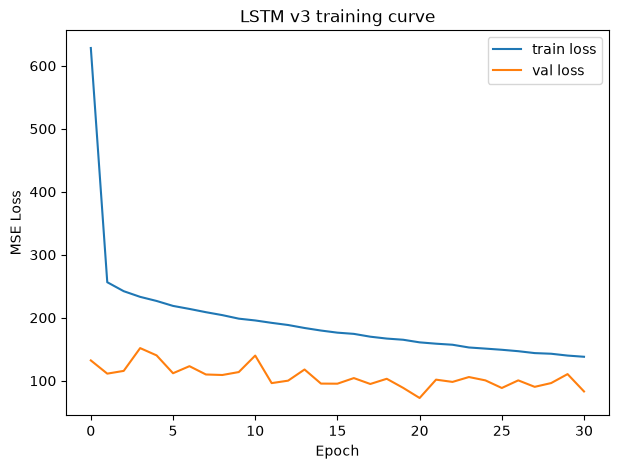

In [53]:
plt.figure(figsize=(7,5))
plt.plot(history_lstm3.history['loss'], label='train loss')
plt.plot(history_lstm3.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('LSTM v3 training curve')
plt.show()

In [54]:
lstm4 = keras.Sequential([
    keras.layers.Input(shape=(X_train_n.shape[1], X_train_n.shape[2])),
    keras.layers.LSTM(48, dropout=0.2, recurrent_dropout=0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
lstm4.compile(optimizer='adam', loss='mse')
early_stop_lstm4 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_lstm4 = lstm4.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=60, batch_size=512, verbose=1, callbacks=[early_stop_lstm4]
)

lstm4_pred = lstm4.predict(X_test_n, verbose=0).flatten()
lstm4_mae = mean_absolute_error(y_test, lstm4_pred)
lstm4_rmse = np.sqrt(mean_squared_error(y_test, lstm4_pred))
lstm4_r2 = r2_score(y_test, lstm4_pred)
print(f'LSTM v4 (recurrent_dropout restored, 48 units) -> MAE: {lstm4_mae:.3f}  RMSE: {lstm4_rmse:.3f}  R2: {lstm4_r2:.4f}')
print(f'Stopped at epoch {len(history_lstm4.history["loss"])}')

Epoch 1/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 651.2399 - val_loss: 51.4138
Epoch 2/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 182.6785 - val_loss: 53.7155
Epoch 3/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 168.8153 - val_loss: 56.0963
Epoch 4/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 161.9427 - val_loss: 57.8704
Epoch 5/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 156.4856 - val_loss: 57.2755
Epoch 6/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 151.9127 - val_loss: 56.4007
Epoch 7/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 147.5020 - val_loss: 58.5348
Epoch 8/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 143.0303 - val_loss: 53.3424
Epoch 9/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 139.1433 - val_loss: 60.4806
Epoch 10/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 135.6939 - val_loss: 57.5910
Epoch 11/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 131.

In [55]:
final_results = pd.DataFrame({
    'Model': ['Coulomb Counting', 'Random Forest', 'MLP', 'LSTM'],
    'MAE (%)': [cc_mae, rf_mae, mlp2_mae, lstm2_mae],
    'RMSE (%)': [cc_rmse, rf_rmse, mlp2_rmse, lstm2_rmse],
    'R2': [cc_r2, rf_r2, mlp2_r2, lstm2_r2],
    'Params/Nodes': [None, rf.n_estimators, mlp2.count_params(), lstm2.count_params()]
}).sort_values('MAE (%)').reset_index(drop=True)

final_results

,Model,MAE (%),RMSE (%),R2,Params/Nodes
0,Random Forest,3.586516,5.151521,0.966080,200.0
1,Coulomb Counting,4.265573,7.539591,0.927342,NaN
2,MLP,4.360845,5.863253,0.956059,1729.0
3,LSTM,5.755613,7.319377,0.931524,5153.0


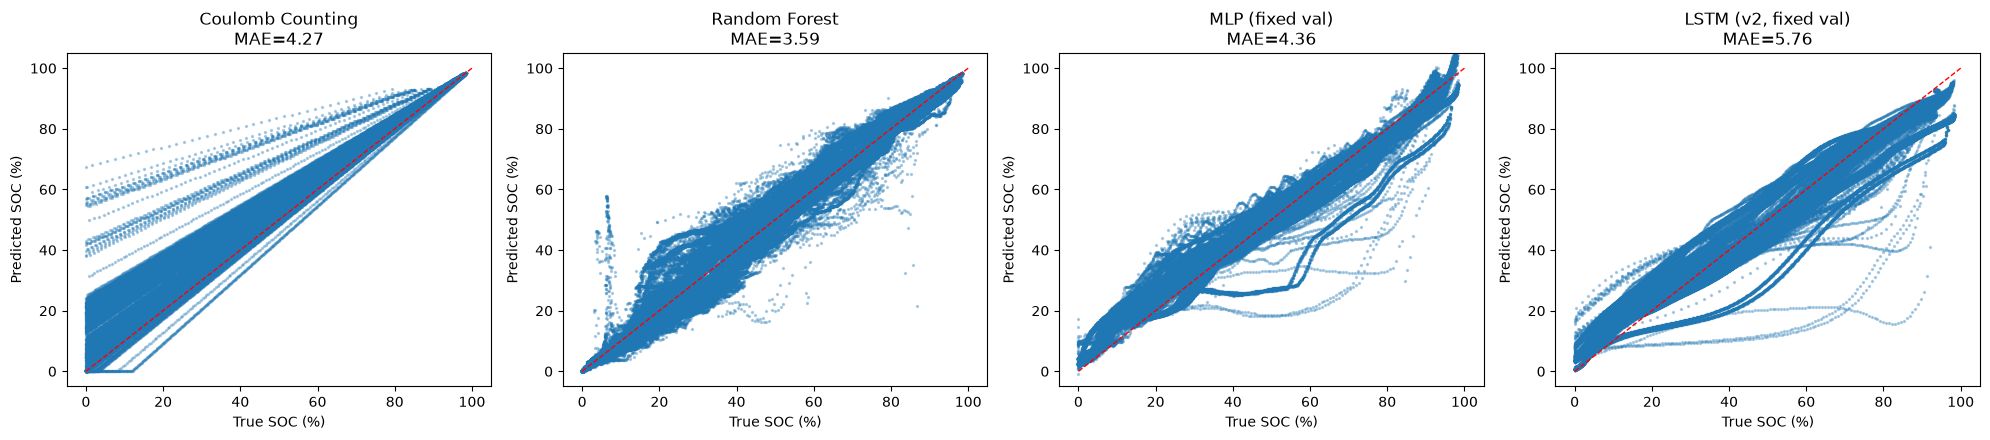

In [56]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

final_model_data = [
    ('Coulomb Counting', cc_true, cc_preds),
    ('Random Forest', y_test, rf_pred),
    ('MLP (fixed val)', y_test, mlp2_pred),
    ('LSTM (v2, fixed val)', y_test, lstm2_pred),
]

for ax, (name, true_vals, pred_vals) in zip(axes, final_model_data):
    ax.scatter(true_vals, pred_vals, s=2, alpha=0.3)
    ax.plot([0, 100], [0, 100], 'r--', linewidth=1)
    ax.set_xlabel('True SOC (%)')
    ax.set_ylabel('Predicted SOC (%)')
    ax.set_title(f'{name}\nMAE={dict(zip(final_results.Model, final_results["MAE (%)"]))[name.split(" (")[0] if "(" in name else name]:.2f}')
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)

plt.tight_layout()
plt.savefig('soc_final_comparison.png', dpi=120)
plt.show()

In [57]:
import joblib

rf.set_params(n_jobs=1)  # smaller/cleaner pickle, avoids parallel-backend refs
joblib.dump(rf, 'model_rf_soc.joblib')
mlp2.save('model_mlp_soc.keras')
lstm2.save('model_lstm_soc.keras')

# save normalization stats too — needed at inference time on-device
np.savez('soc_norm_stats.npz', mean=mean, std=std)

print("Saved: model_rf_soc.joblib, model_mlp_soc.keras, model_lstm_soc.keras, soc_norm_stats.npz")

Saved: model_rf_soc.joblib, model_mlp_soc.keras, model_lstm_soc.keras, soc_norm_stats.npz
